# Vector 거리 계산

## 측정 방식 비교
### 맨해튼 거리
* 두 점 사이의 수평과 수직 거리의 합으로 계산
* 실제 도로망처럼 직각으로 이동하는 거리를 측정할 때 적합
* 수식: |p1-q1| + |p2-q2|

### 유클리드 거리
* 두 점 사이의 최단 직선 거리를 계산
* 피타고라스 정리를 기반으로 한 가장 직관적인 거리 측정 방법
* 수식: √(x1-y1)² + (x2-y2)² + … + (xn-yn)²

### 코사인 유사도
* 두 벡터 간의 각도를 이용해 유사도를 측정
* -1에서 1 사이의 값을 가지며, 1에 가까울수록 유사
* 벡터의 크기와 관계없이 방향성만 고려

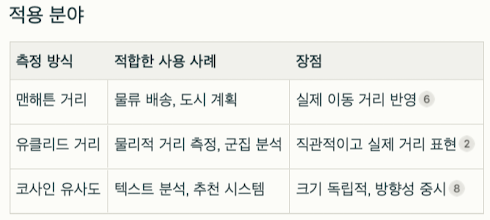

In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import manhattan_distances, euclidean_distances, cosine_similarity

# 문장 데이터 Corpus와 문서 이름
corpus = [
    "Hello World",
    "Hello World World",
    "Hello Hello World",
    "Hello Hello World World"
]
doc_names = ["Doc1", "Doc2", "Doc3", "Doc4"]

# BoW 계산
## Bag of Words (백오브 워즈) 텍스트 데이터를 숫자로 변환하는 가장 기본적인 방법
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(corpus)
print("BoW 행렬:\n", bow_matrix.toarray())
print("BoW 특성 이름:\n", bow_vectorizer.get_feature_names_out())

BoW 행렬:
 [[1 1]
 [1 2]
 [2 1]
 [2 2]]
BoW 특성 이름:
 ['hello' 'world']


In [2]:
# 맨하탄 거리 계산
manhattan_dist = manhattan_distances(bow_matrix)
print("\n맨하탄 거리:")
print("        ", end="")
for doc_name in doc_names:
    print(f"{doc_name:>10}", end="")
print()
for i, doc_name in enumerate(doc_names):
    print(f"{doc_name:>8}", end="")
    for dist in manhattan_dist[i]:
        print(f"{dist:10.2f}", end="")
    print()


맨하탄 거리:
              Doc1      Doc2      Doc3      Doc4
    Doc1      0.00      1.00      1.00      2.00
    Doc2      1.00      0.00      2.00      1.00
    Doc3      1.00      2.00      0.00      1.00
    Doc4      2.00      1.00      1.00      0.00


In [3]:
# 유클리드 거리 계산
euclidean_dist = euclidean_distances(bow_matrix)
print("\n유클리드 거리:")
print("        ", end="")
for doc_name in doc_names:
    print(f"{doc_name:>10}", end="")
print()
for i, doc_name in enumerate(doc_names):
    print(f"{doc_name:>8}", end="")
    for dist in euclidean_dist[i]:
        print(f"{dist:10.2f}", end="")
    print()


유클리드 거리:
              Doc1      Doc2      Doc3      Doc4
    Doc1      0.00      1.00      1.00      1.41
    Doc2      1.00      0.00      1.41      1.00
    Doc3      1.00      1.41      0.00      1.00
    Doc4      1.41      1.00      1.00      0.00


In [4]:
# 코사인 거리 계산 (1 - 코사인 유사도 = 코사인 거리)
cosine_sim = cosine_similarity(bow_matrix)
cosine_dist = 1 - cosine_sim
print("\n코사인 거리:")
print("        ", end="")
for doc_name in doc_names:
    print(f"{doc_name:>10}", end="")
print()
for i, doc_name in enumerate(doc_names):
    print(f"{doc_name:>8}", end="")
    for dist in cosine_dist[i]:
        print(f"{dist:10.2f}", end="")
    print()


코사인 거리:
              Doc1      Doc2      Doc3      Doc4
    Doc1      0.00      0.05      0.05      0.00
    Doc2      0.05      0.00      0.20      0.05
    Doc3      0.05      0.20      0.00      0.05
    Doc4      0.00      0.05      0.05      0.00
